In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

In [ ]:
(X_train, Y_train), (X_test, Y_test) = fashion_mnist.load_data()
print("Training Images Shape:", X_train.shape)
print("Training Labels Shape:", Y_train.shape)
print("Testing Images Shape:", X_test.shape)
print("Testing Labels Shape:", Y_test.shape)

Training Images Shape: (60000, 28, 28)
Training Labels Shape: (60000,)
Testing Images Shape: (10000, 28, 28)
Testing Labels Shape: (10000,)


<function matplotlib.pyplot.show(close=None, block=None)>

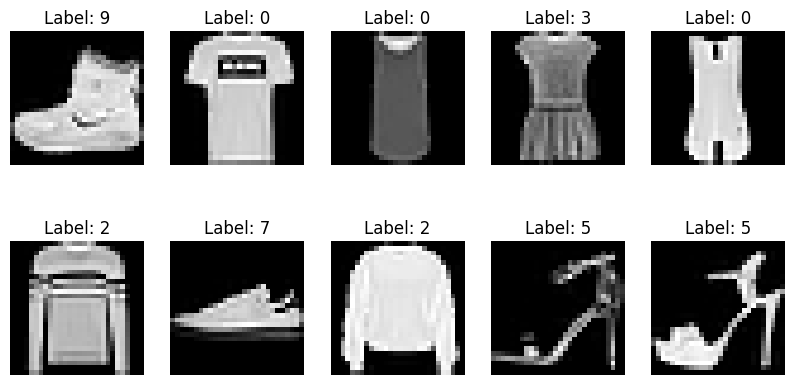

In [ ]:
plt.figure(figsize=(10,5))
for i in range(10):
  plt.subplot(2, 5, i+1)
  plt.imshow(X_train[i], cmap='gray')
  plt.title(f"Label: {Y_train[i]}")
  plt.axis('off')
plt.show

In [ ]:
X_train = X_train/255.0
X_test = X_test/255.0

In [ ]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [ ]:
Y_train = to_categorical(Y_train, 10)
Y_test = to_categorical(Y_test, 10)

In [ ]:
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(MaxPooling2D((2, 2)))

#Second convolution layer
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

#flatten layer
model.add(Flatten())

#fully connected layer
model.add(Dense(128, activation='relu'))

#dropout layer

model.add(Dropout(0.5))

#output layer
model.add(Dense(10, activation='softmax')mb)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics =['accuracy'])

In [ ]:
history = model.fit(X_train, Y_train, epochs=10, batch_size=32, validation_data=(X_test, Y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 61s 32ms/step - accuracy: 0.8084 - loss: 0.5355 - val_accuracy: 0.8666 - val_loss: 0.3662
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 62s 33ms/step - accuracy: 0.8683 - loss: 0.3663 - val_accuracy: 0.8871 - val_loss: 0.3139
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 64s 34ms/step - accuracy: 0.8854 - loss: 0.3142 - val_accuracy: 0.8958 - val_loss: 0.2870
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 31ms/step - accuracy: 0.8965 - loss: 0.2847 - val_accuracy: 0.9004 - val_loss: 0.2730
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 32ms/step - accuracy: 0.9066 - loss: 0.2593 - val_accuracy: 0.9058 - val_loss: 0.2547
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 31ms/step - accuracy: 0.9104 - loss: 0.2453 - val_accuracy: 0.9056 - val_loss: 0.2541
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 58s 31ms/step - accuracy: 0.9164 - loss: 0.2289 - val_accuracy: 0.9090 - val_loss: 0.2576
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 32ms/step - accuracy: 0.9194 -

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, Y_test)
print('Test Loss: {test_loss}')
print('Test Accuracy: {test_accuracy}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9063 - loss: 0.2718
Test Loss: {test_loss}
Test Accuracy: {test_accuracy}


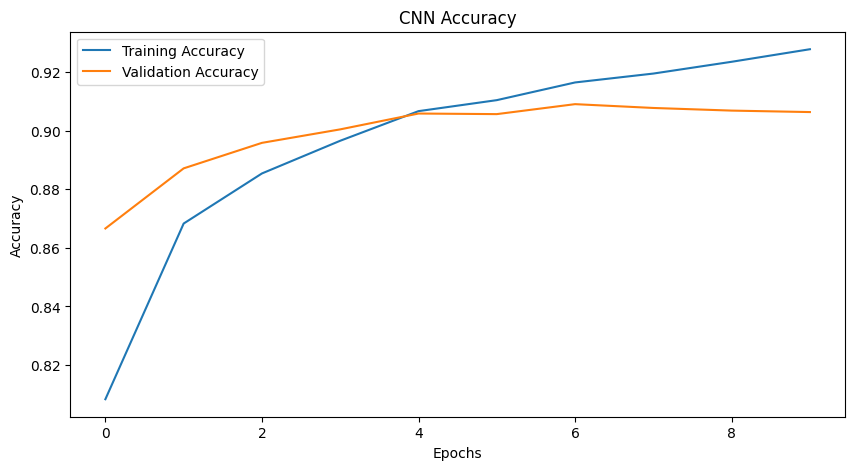

In [ ]:
#Accuracy score
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('CNN Accuracy')
plt.legend()
plt.show()

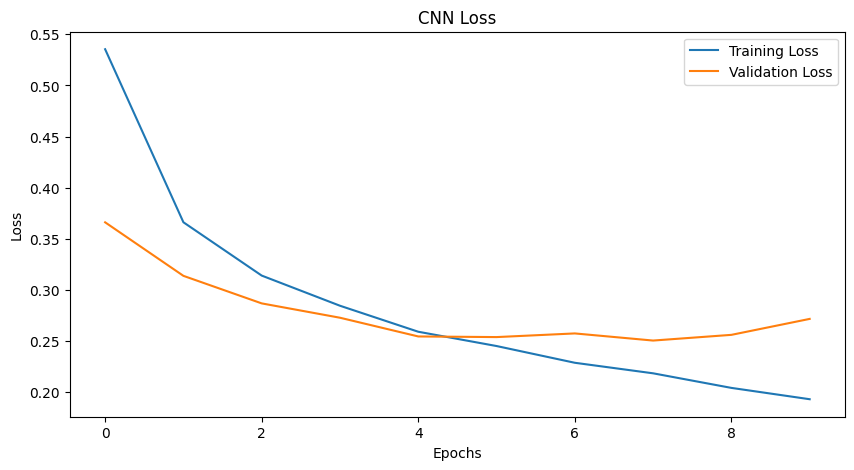

In [ ]:
#loss curve
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('CNN Loss')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


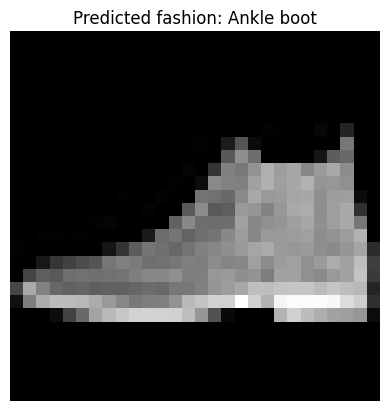

In [25]:
sample = X_test[0]
prediction = model.predict(sample.reshape(1, 28, 28, 1))
predicted_label = np.argmax(prediction)

# Define Fashion MNIST class names (if not already defined in global scope)
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
predicted_fashion_name = class_names[predicted_label]

plt.imshow(sample.reshape(28, 28), cmap='gray')
plt.title(f"Predicted fashion: {predicted_fashion_name}")
plt.axis('off')
plt.show()

Saving OIP-1378541966.jpg to OIP-1378541966.jpg


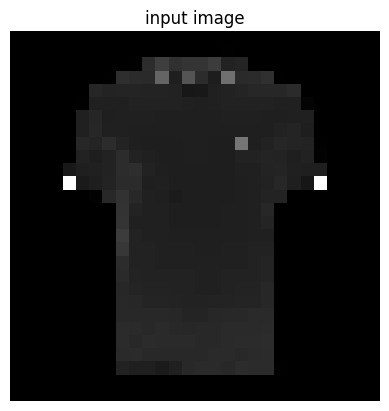

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Predicted Fashion Item: T-shirt/top
Predicted Probability: 97.03241 %


In [26]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import cv2

# Define Fashion MNIST class names
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

uploaded = files.upload()
img_path=list(uploaded.keys())[0]
img=cv2.imread(img_path,cv2.IMREAD_GRAYSCALE)
img=cv2.resize(img,(28,28))
img=255-img
img=img/255.0
plt.imshow(img,cmap='gray')
plt.title("input image")
plt.axis('off')
plt.show()
img=img.reshape(1,28,28,1)
prediction=model.predict(img)
predicted_label = np.argmax(prediction)
predicted_fashion_name = class_names[predicted_label]
print(f"Predicted Fashion Item: {predicted_fashion_name}")
print("Predicted Probability:",np.max(prediction)*100,"%")